# Explainable Plant Disease Detection System Using CNN and Transfer Learning

In [74]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [75]:
import tensorflow as tf

## 1. Import Libraries

In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

## 2. Load Dataset

In [77]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))
print("\nClass Names:")

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Number of classes: 15

Class Names:
1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy


## 3. Dataset Exploration

In [78]:
classes = sorted(os.listdir(dataset_path))

print("Number of Classes:", len(classes))
print("\nClass Names:\n")

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

Number of Classes: 15

Class Names:

1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy


In [79]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution:\n")

for cls in sorted(class_counts.keys()):
    print(f"{cls:<45} : {class_counts[cls]}")

print("\nTotal Images:", sum(class_counts.values()))


Class Distribution:

Pepper__bell___Bacterial_spot                 : 997
Pepper__bell___healthy                        : 1478
Potato___Early_blight                         : 1000
Potato___Late_blight                          : 1000
Potato___healthy                              : 152
Tomato_Bacterial_spot                         : 2127
Tomato_Early_blight                           : 1000
Tomato_Late_blight                            : 1909
Tomato_Leaf_Mold                              : 952
Tomato_Septoria_leaf_spot                     : 1771
Tomato_Spider_mites_Two_spotted_spider_mite   : 1676
Tomato__Target_Spot                           : 1404
Tomato__Tomato_YellowLeaf__Curl_Virus         : 3209
Tomato__Tomato_mosaic_virus                   : 373
Tomato_healthy                                : 1591

Total Images: 20639


## 4. Image Preprocessing

In [80]:
img_size = 64
batch_size = 64

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


## 5. Data Augmentation


In [81]:
train_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_data = train_aug.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 16516 images belonging to 15 classes.


## 6. Custom CNN Model

In [82]:
num_classes = len(classes)

print("Number of Classes:", num_classes)

Number of Classes: 15


In [83]:
cnn_model = models.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,719 (112.18 KB)

 Trainable params: 28,719 (112.18 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 73s 276ms/step - accuracy: 0.2337 - loss: 2.3598 - val_accuracy: 0.3605 - val_loss: 1.9527
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 72s 276ms/step - accuracy: 0.4163 - loss: 1.7778 - val_accuracy: 0.3557 - val_loss: 2.0175
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 70s 272ms/step - accuracy: 0.5017 - loss: 1.5186 - val_accuracy: 0.3205 - val_loss: 2.4495
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 71s 274ms/step - accuracy: 0.5518 - loss: 1.3570 - val_accuracy: 0.4520 - val_loss: 1.8160
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 71s 275ms/step - accuracy: 0.5882 - loss: 1.2400 - val_accuracy: 0.4961 - val_loss: 1.6490


## 7. Transfer Learning Model

In [85]:
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

base_model.trainable = True

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_64             │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 2,389,775 (9.12 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [86]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 186s 601ms/step - accuracy: 0.2619 - loss: 2.2749 - val_accuracy: 0.0813 - val_loss: 2.6633
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 154s 594ms/step - accuracy: 0.4290 - loss: 1.8115 - val_accuracy: 0.0813 - val_loss: 2.6732
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 154s 594ms/step - accuracy: 0.5016 - loss: 1.5634 - val_accuracy: 0.0485 - val_loss: 2.8649
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 155s 599ms/step - accuracy: 0.5717 - loss: 1.3460 - val_accuracy: 0.0485 - val_loss: 3.2738


## 8. Model Evaluation

In [99]:
y_true = val_data.classes

y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_data.class_indices.keys())

# Check what classes the model is predicting
unique, counts = np.unique(y_pred, return_counts=True)

print("Predicted Class Distribution:")
for u, c in zip(unique, counts):
    print(class_names[u], ":", c)

# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step
Predicted Class Distribution:
Pepper__bell___Bacterial_spot : 509
Pepper__bell___healthy : 300
Potato___Early_blight : 187
Potato___Late_blight : 20
Tomato_Bacterial_spot : 262
Tomato_Early_blight : 116
Tomato_Late_blight : 236
Tomato_Leaf_Mold : 67
Tomato_Septoria_leaf_spot : 225
Tomato_Spider_mites_Two_spotted_spider_mite : 204
Tomato__Target_Spot : 390
Tomato__Tomato_YellowLeaf__Curl_Virus : 592
Tomato__Tomato_mosaic_virus : 17
Tomato_healthy : 997
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.28      0.71      0.40       199
                     Pepper__bell___healthy       0.58      0.59      0.58       295
                      Potato___Early_blight       0.64      0.60      0.62       200
                       Potato___Late_blight       0.15      0.01      0.03       200
                           Potato___healthy       0.00      0.00      0.00   

## 9. Confusion Matrix

65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step


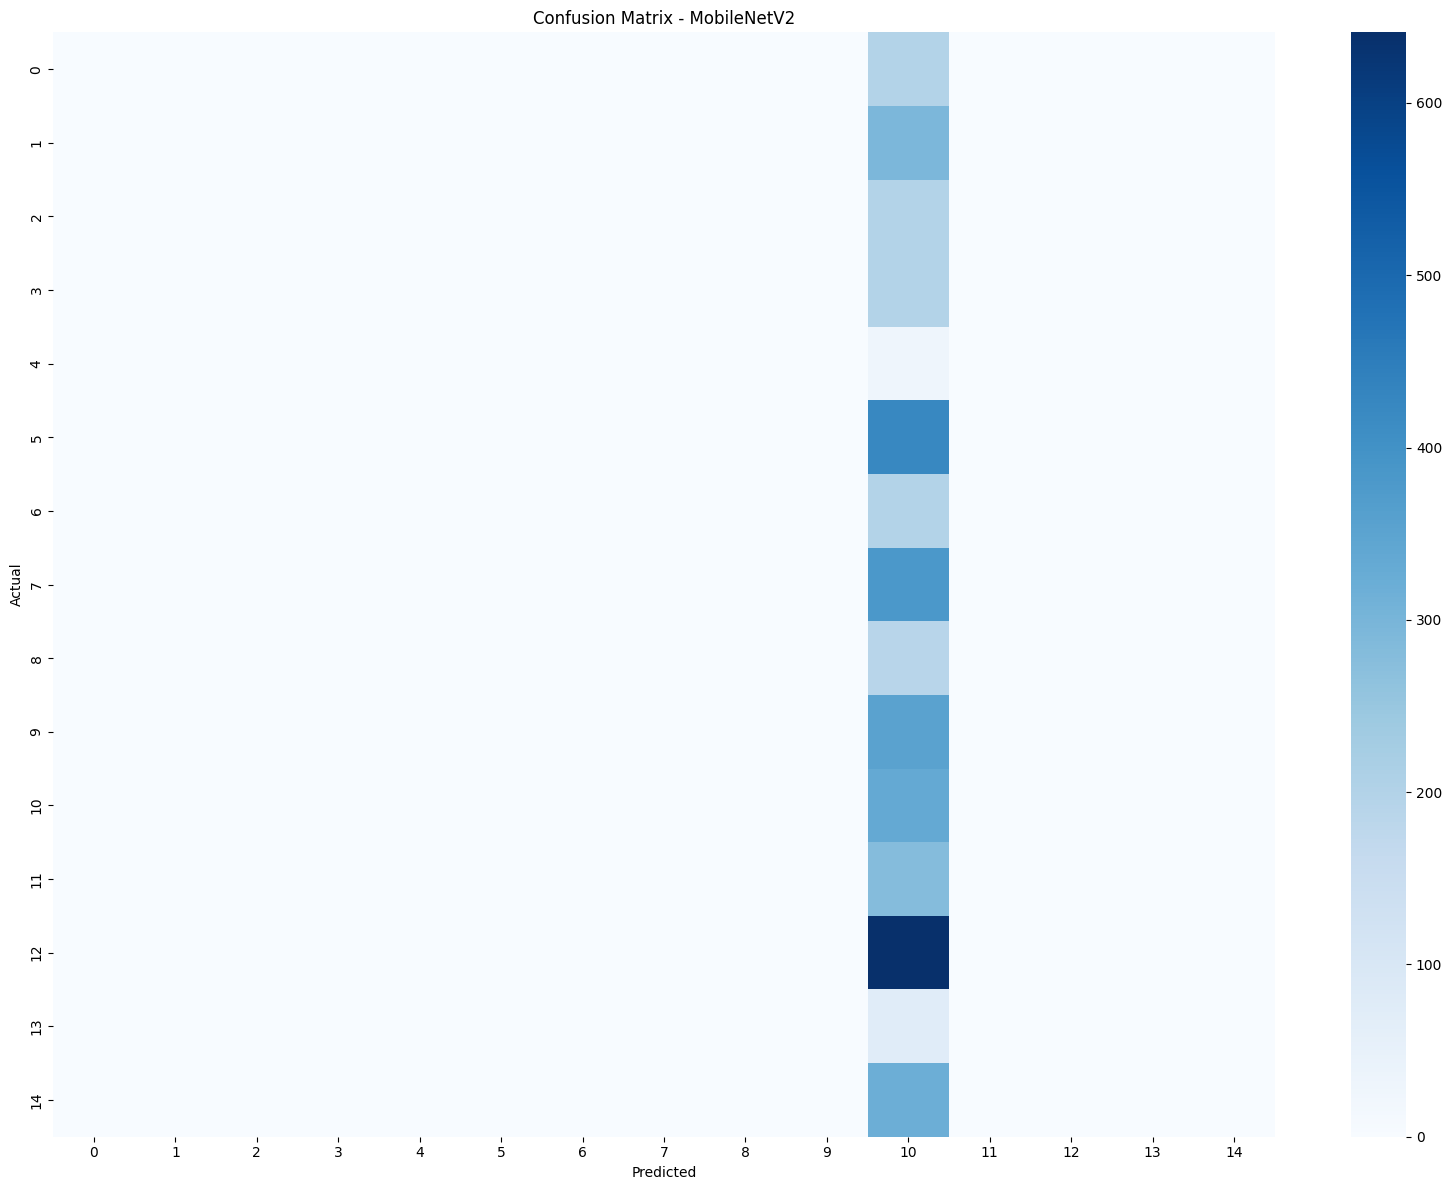

In [100]:
y_true = val_data.classes
y_pred_probs = mobilenet_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16,12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## 10. Accuracy and Loss Curves

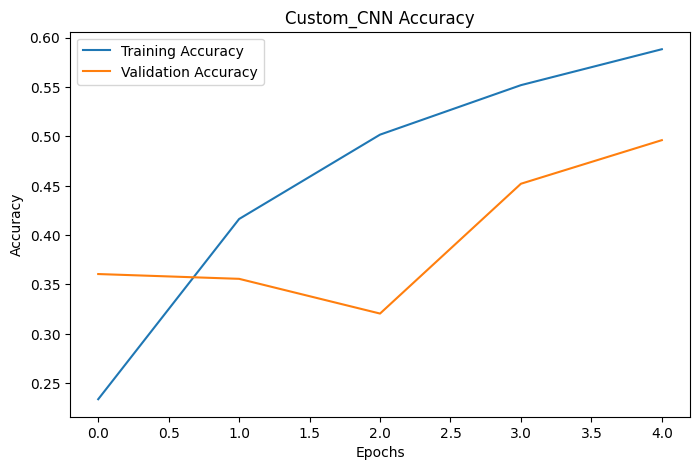

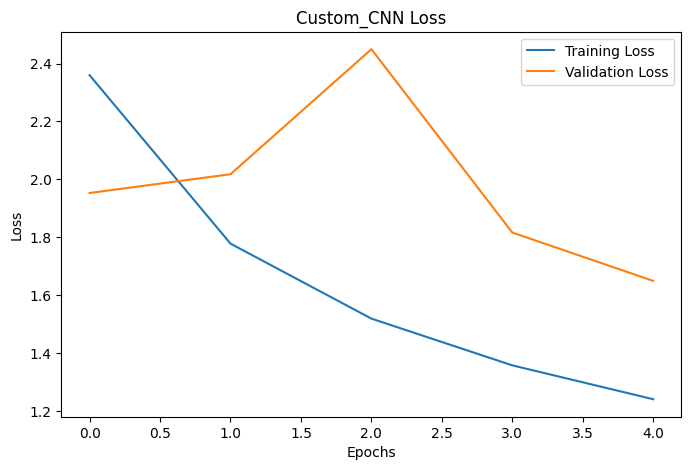

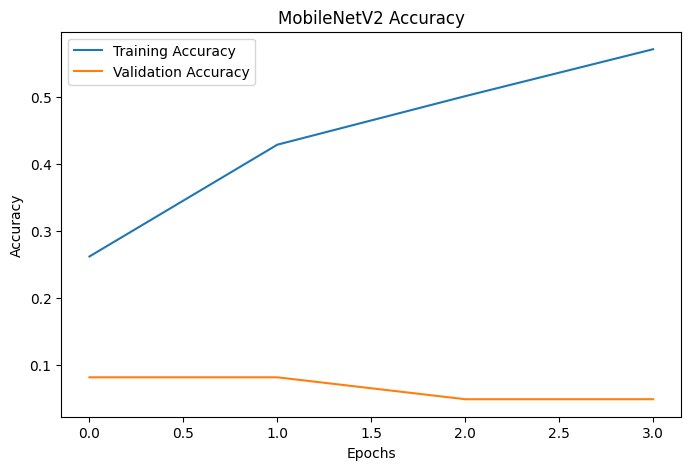

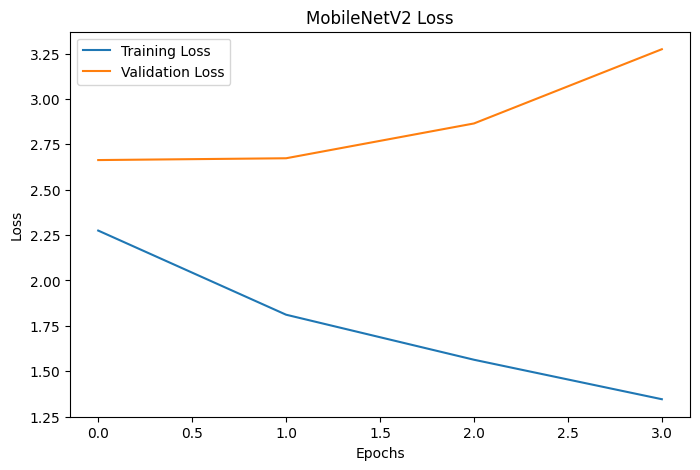

In [94]:
def plot_training(history, model_name):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(model_name + "_accuracy.png")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(model_name + "_loss.png")
    plt.show()

plot_training(history_cnn, "Custom_CNN")
plot_training(history_mobile, "MobileNetV2")

## 11. Future Enhancement: Grad-CAM Explainability

## 12. Model Comparison

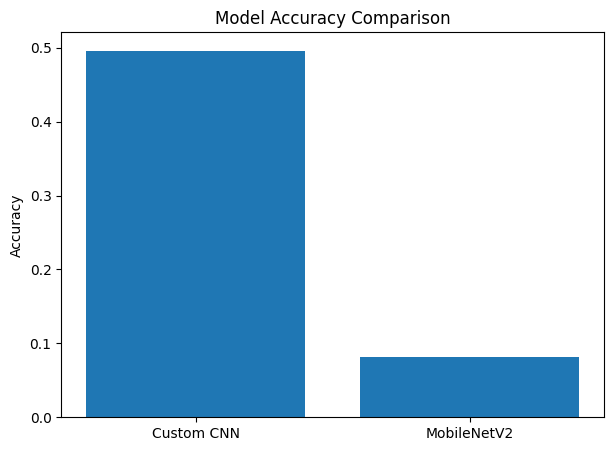

Custom CNN Accuracy: 0.4961183965206146 Loss: 1.6489713191986084
MobileNetV2 Accuracy: 0.081271231174469 Loss: 2.6632614135742188


In [101]:
models_list = ["Custom CNN", "MobileNetV2"]
accuracy_list = [cnn_acc, mobile_acc]
loss_list = [cnn_loss, mobile_loss]

plt.figure(figsize=(7,5))
plt.bar(models_list, accuracy_list)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.savefig("model_comparison.png")
plt.show()

for model, acc, loss in zip(models_list, accuracy_list, loss_list):
    print(model, "Accuracy:", acc, "Loss:", loss)

## 13. Save Models

In [105]:
cnn_model.save("custom_cnn_model.keras")
mobilenet_model.save("mobilenetv2_model.keras")

## 14. Conclusion

In this project, a CNN-based plant disease detection system was developed using the PlantVillage dataset. A custom CNN model and a MobileNetV2-based architecture were implemented and evaluated using standard classification metrics. The generated confusion matrix, classification report, and performance curves provide insights into model behavior. Future work includes implementing Grad-CAM explainability and further hyperparameter tuning to improve classification performance.